In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Bidirectional, Dropout,
    Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping

PROJECT_ROOT_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData"
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT_PATH, "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT_PATH, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

SEQUENCE_LENGTH = 100
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EEG_BANDS = ['Delta_TP9', 'Theta_TP9', 'Alpha_TP9', 'Beta_TP9', 'Gamma_TP9']

sns.set_style("whitegrid")

print("Configuration complete.")

Configuration complete.


In [2]:
print("--- Scanning for all trial files ---")
all_trial_files = [p for student_dir in glob(os.path.join(PROCESSED_DATA_PATH, "*")) 
                   for p in glob(os.path.join(student_dir, "*_eeg.csv"))]

print(f"Found a total of {len(all_trial_files)} EEG trial files.")
print("First 5 files found:")
for f in all_trial_files[:5]:
    print(f" - {os.path.basename(f)}")

np.random.seed(42)
np.random.shuffle(all_trial_files)
split_index = int(len(all_trial_files) * (1 - VALIDATION_SPLIT))
train_files = all_trial_files[:split_index]
val_files = all_trial_files[split_index:]

print(f"\nSuccessfully split files into {len(train_files)} training files and {len(val_files)} validation files.")

--- Scanning for all trial files ---
Found a total of 2364 EEG trial files.
First 5 files found:
 - student_1_trial_0_eeg.csv
 - student_1_trial_10_eeg.csv
 - student_1_trial_11_eeg.csv
 - student_1_trial_12_eeg.csv
 - student_1_trial_13_eeg.csv

Successfully split files into 1891 training files and 473 validation files.


In [3]:
print("--- Calculating scaling statistics from the training set ---")

if not train_files:
    raise ValueError("No training files were found. Cannot proceed.")

all_train_eeg_data = pd.concat([pd.read_csv(f)[EEG_BANDS] for f in train_files])

train_mean = all_train_eeg_data.mean().values
train_std = all_train_eeg_data.std().values

print("Scaling statistics calculated successfully.")

--- Calculating scaling statistics from the training set ---


C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\412676218.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  all_train_eeg_data = pd.concat([pd.read_csv(f)[EEG_BANDS] for f in train_files])
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\412676218.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  all_train_eeg_data = pd.concat([pd.read_csv(f)[EEG_BANDS] for f in train_files])
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\412676218.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  all_train_eeg_data = pd.concat([pd.read_csv(f)[EEG_BANDS] for f in train_files])
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\412676218.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  all_train_eeg_data = pd.concat([pd.read_csv(f)[EEG_BANDS] for f in train_files])


Scaling statistics calculated successfully.


In [4]:
print("--- Inspecting Calculated Statistics ---")
print(f"\nMean values for each of the {len(train_mean)} features:\n{train_mean}")
print(f"\nStandard Deviation for each of the {len(train_std)} features:\n{train_std}")

--- Inspecting Calculated Statistics ---

Mean values for each of the 5 features:
[0.78465461 0.60174996 0.80129813 0.47873342 0.0747109 ]

Standard Deviation for each of the 5 features:
[0.40548863 0.33156575 0.29508984 0.20864094 0.28623988]


In [5]:
def create_dataset_in_memory(file_paths, mean, std, sequences_per_trial=5):
    """
    Loads trials into memory, scales them, and creates multiple augmented sequences.
    """
    X_list, y_list = [], []
    epsilon = 1e-8 

    for file_path in file_paths:
        try:
            meta_df = pd.read_csv(file_path.replace("_eeg.csv", "_meta.csv"))
            response_time = meta_df['ResponseTime'].iloc[0]
            eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
            
            if len(eeg_data) < SEQUENCE_LENGTH:
                continue

            eeg_data_scaled = (eeg_data - mean) / (std + epsilon)
            
            # Data Augmentation: Create multiple random slices from each trial
            for _ in range(sequences_per_trial):
                start_index = np.random.randint(0, len(eeg_data_scaled) - SEQUENCE_LENGTH + 1)
                sequence = eeg_data_scaled[start_index : start_index + SEQUENCE_LENGTH]
                X_list.append(sequence)
                y_list.append(response_time)
        except Exception as e:
            print(f"Warning: Skipping file {os.path.basename(file_path)}. Reason: {e}")
            continue
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

print("Data generation function `create_dataset_in_memory` is defined.")

Data generation function `create_dataset_in_memory` is defined.


In [6]:
print("--- Loading and augmenting training data into memory... ---")
X_train, y_train = create_dataset_in_memory(train_files, train_mean, train_std, sequences_per_trial=5)
print(f"Augmented training data shape: X={X_train.shape}, y={y_train.shape}")

print("\n--- Loading validation data into memory... ---")
# No augmentation for the validation set, we want a consistent evaluation
X_val, y_val = create_dataset_in_memory(val_files, train_mean, train_std, sequences_per_trial=1)
print(f"Validation data shape: X={X_val.shape}, y={y_val.shape}")

--- Loading and augmenting training data into memory... ---


C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed ty

Augmented training data shape: X=(9450, 100, 5), y=(9450,)

--- Loading validation data into memory... ---


C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10844\1735859463.py:12: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_data = pd.read_csv(file_path)[EEG_BANDS].values


Validation data shape: X=(473, 100, 5), y=(473,)


In [7]:
print("--- Inspecting a single sample from the training set ---")
if len(X_train) > 0:
    sample_x = X_train[0]
    sample_y = y_train[0]
    
    print(f"Shape of one X sample (timesteps, features): {sample_x.shape}")
    print(f"Data type of one X sample: {sample_x.dtype}")
    print(f"\nValue of one y sample (response_time): {sample_y}")
    print(f"Data type of one y sample: {sample_y.dtype}")
else:
    print("No training data was generated.")

--- Inspecting a single sample from the training set ---
Shape of one X sample (timesteps, features): (100, 5)
Data type of one X sample: float32

Value of one y sample (response_time): 36.275474548339844
Data type of one y sample: float32


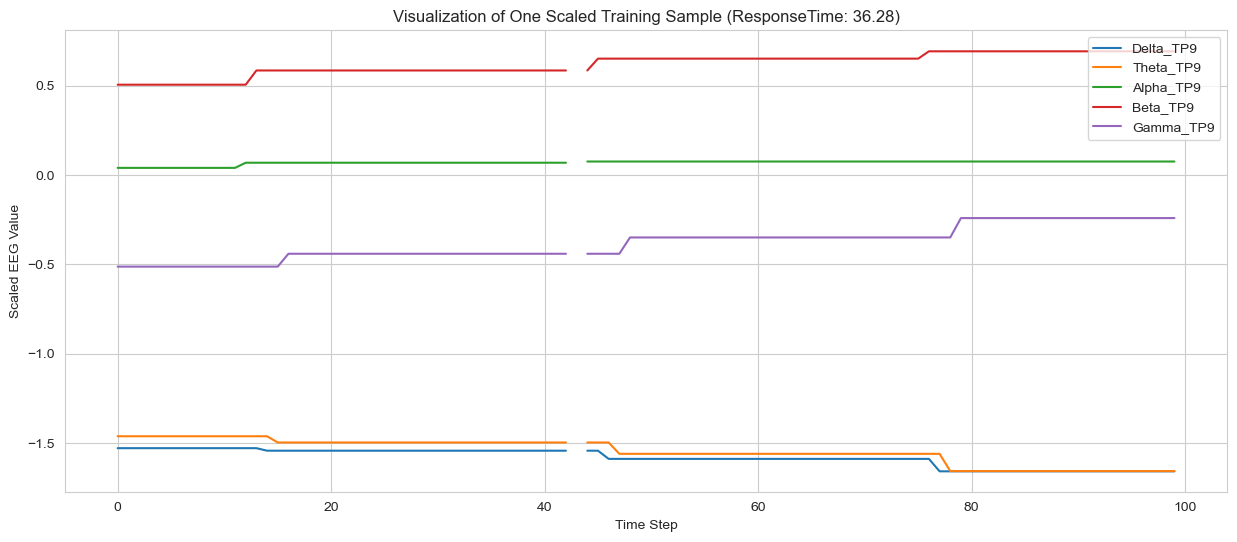

In [8]:
if len(X_train) > 0:
    plt.figure(figsize=(15, 6))
    for i, band_name in enumerate(EEG_BANDS):
        plt.plot(sample_x[:, i], label=band_name)
    
    plt.title(f'Visualization of One Scaled Training Sample (ResponseTime: {sample_y:.2f})')
    plt.xlabel('Time Step')
    plt.ylabel('Scaled EEG Value')
    plt.legend()
    plt.show()

In [10]:
print("--- Building efficient in-memory TensorFlow datasets ---")

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print("Datasets are ready for training.")

--- Building efficient in-memory TensorFlow datasets ---
Datasets are ready for training.


In [11]:
def build_bilstm_model(input_shape, lstm_units=16, dense_units=16, dropout_rate=0.4, learning_rate=0.0005):
    """Builds a tunable BiLSTM model."""
    model = Sequential([
        Bidirectional(LSTM(lstm_units, return_sequences=True), input_shape=input_shape),
        Dropout(dropout_rate),
        Bidirectional(LSTM(lstm_units // 2)),
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

def build_tcnn_model(input_shape, filters=32, dense_units=32, dropout_rate=0.4, learning_rate=0.0005):
    """Builds a Temporal 1D CNN model."""
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),
        Conv1D(filters=filters*2, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

print("Model-building functions `build_bilstm_model` and `build_tcnn_model` are defined.")

Model-building functions `build_bilstm_model` and `build_tcnn_model` are defined.


In [12]:
input_shape = (X_train.shape[1], X_train.shape[2])

model = build_bilstm_model(input_shape) 

print("--- Model Summary ---")
model.summary()

C:\Users\Enjoy\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 100, 32)             │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 16)                  │           2,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,729 (22.38 KB)

 Trainable params: 5,729 (22.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("Starting model training...")

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining complete.")

Starting model training...
Epoch 1/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - loss: 424.3078 - mae: 15.7551 - val_loss: 411.4985 - val_mae: 15.0456
Epoch 2/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - loss: 412.9120 - mae: 15.4561 - val_loss: 407.0670 - val_mae: 14.8976
Epoch 3/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 425.1482 - mae: 15.5503 - val_loss: 402.6793 - val_mae: 14.7496
Epoch 4/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - loss: 405.9742 - mae: 15.1732 - val_loss: 398.3352 - val_mae: 14.6018
Epoch 5/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - loss: 415.4491 - mae: 15.2456 - val_loss: 394.0349 - val_mae: 14.4544
Epoch 6/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - loss: 421.2784 - mae: 15.2541 - val_loss: 389.7784 - val_mae: 14.3070
Epoch 7/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 389.2259 - mae: 14.6253 - val_loss: 385.5657 - val_mae: 14.1596
Epoch 8/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 400.8788 - mae: 14.88

296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 253.9363 - mae: 10.1217 - val_loss: 243.5655 - val_mae: 9.4405
Epoch 52/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - loss: 252.0403 - mae: 10.0263 - val_loss: 241.3237 - val_mae: 9.3968
Epoch 53/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 262.1313 - mae: 10.2454 - val_loss: 239.1259 - val_mae: 9.3569
Epoch 54/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 258.0366 - mae: 10.1296 - val_loss: 236.9719 - val_mae: 9.3194
Epoch 55/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - loss: 242.8571 - mae: 9.7934 - val_loss: 234.8636 - val_mae: 9.2848
Epoch 56/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 234.6090 - mae: 9.7238 - val_loss: 232.7991 - val_mae: 9.2524
Epoch 57/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - loss: 232.1486 - mae: 9.6585 - val_loss: 230.7785 - val_mae: 9.2232
Epoch 58/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 236.9091 - mae: 9.6638 - val_loss: 228.8016 - val_mae: 9.1968
E

296/296 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - loss: 183.7773 - mae: 9.6712 - val_loss: 186.0737 - val_mae: 9.7499
Epoch 103/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - loss: 181.8380 - mae: 9.5935 - val_loss: 185.9343 - val_mae: 9.7702
Epoch 104/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - loss: 195.5603 - mae: 9.8448 - val_loss: 185.8083 - val_mae: 9.7902
Epoch 105/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - loss: 181.3021 - mae: 9.6589 - val_loss: 185.7044 - val_mae: 9.8083
Epoch 106/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - loss: 192.2095 - mae: 9.8491 - val_loss: 185.6130 - val_mae: 9.8259
Epoch 107/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - loss: 186.0735 - mae: 9.8021 - val_loss: 185.5390 - val_mae: 9.8416
Epoch 108/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - loss: 175.2486 - mae: 9.5990 - val_loss: 185.4713 - val_mae: 9.8574
Epoch 109/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - loss: 179.2448 - mae: 9.7460 - val_loss: 185.4072 - val_ma

--- Plotting training and validation history ---


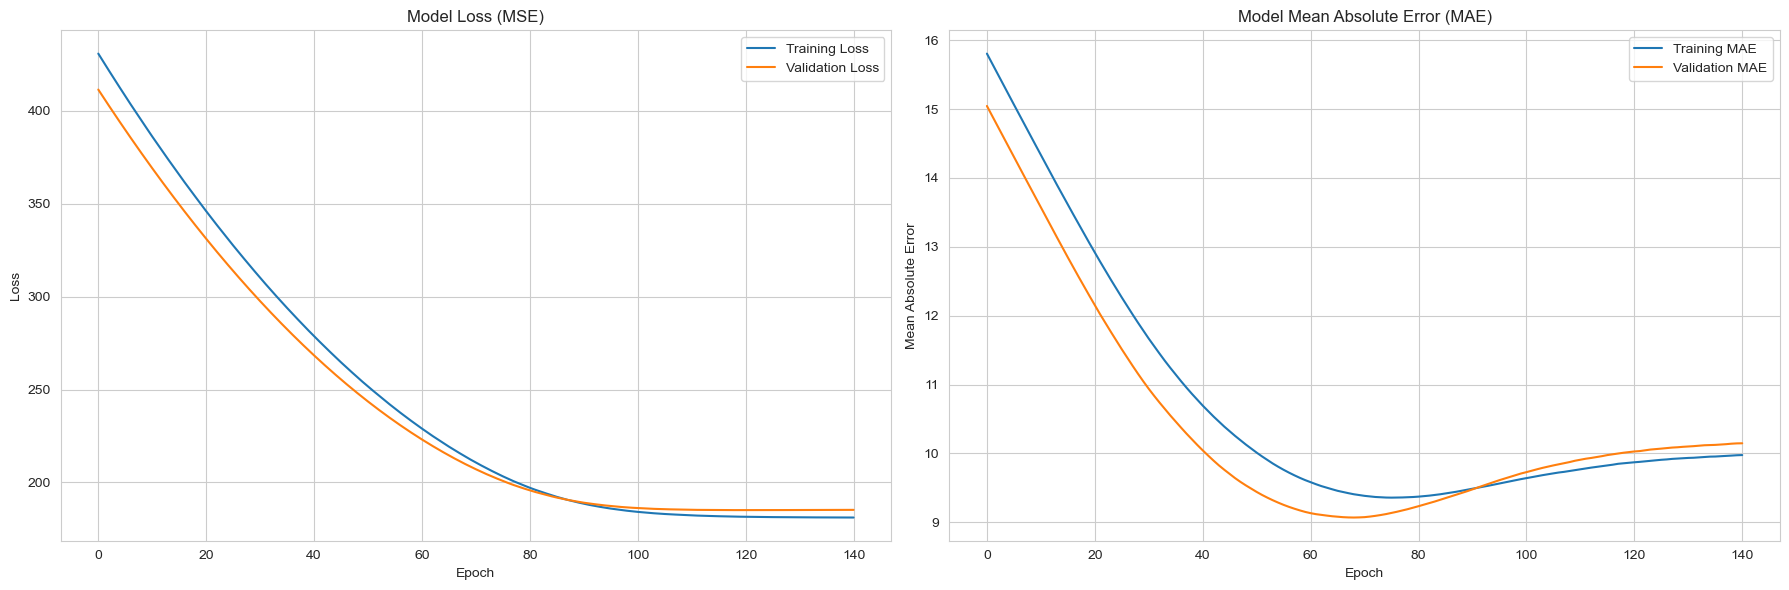

In [14]:
print("--- Plotting training and validation history ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot Loss (Mean Squared Error)
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Metric (Mean Absolute Error)
ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Model Mean Absolute Error (MAE)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
print("--- Final Evaluation on the Validation Set ---")
final_loss, final_mae = model.evaluate(val_dataset, verbose=0)

print(f"Final Validation Loss (MSE): {final_loss:.4f}")
print(f"Final Validation Mean Absolute Error (MAE): {final_mae:.4f}")

# Save the model weights with a descriptive name
weights_path = os.path.join(MODELS_DIR, "bilstm_model_final.weights.h5")
model.save_weights(weights_path)

print(f"\nModel weights saved to: {weights_path}")

--- Final Evaluation on the Validation Set ---
Final Validation Loss (MSE): 185.1299
Final Validation Mean Absolute Error (MAE): 10.0282

Model weights saved to: C:\Users\Enjoy\OneDrive\Desktop\STData\models\bilstm_model_final.weights.h5


In [17]:
input_shape = (X_train.shape[1], X_train.shape[2])

model = build_tcnn_model(input_shape) 

print("--- Model Summary ---")
model.summary()

--- Model Summary ---


C:\Users\Enjoy\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 98, 32)              │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 49, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 49, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 47, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 23, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 23, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1472)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │          47,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,889 (210.50 KB)

 Trainable params: 53,889 (210.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("Starting model training...")

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining complete.")

Starting model training...
Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 442.3416 - mae: 16.0197 - val_loss: 411.4985 - val_mae: 15.0456
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 420.8054 - mae: 15.6206 - val_loss: 407.0670 - val_mae: 14.8976
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 413.8156 - mae: 15.4496 - val_loss: 402.6793 - val_mae: 14.7496
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 419.3315 - mae: 15.4302 - val_loss: 398.3352 - val_mae: 14.6018
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 411.1625 - mae: 15.2324 - val_loss: 394.0349 - val_mae: 14.4544
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 404.7066 - mae: 15.1004 - val_loss: 389.7784 - val_mae: 14.3070
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 394.8618 - mae: 14.7825 - val_loss: 385.5657 - val_mae: 14.1596
Epoch 8/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 393.0485 - mae: 14.7145 - val_loss: 

--- Plotting training and validation history ---


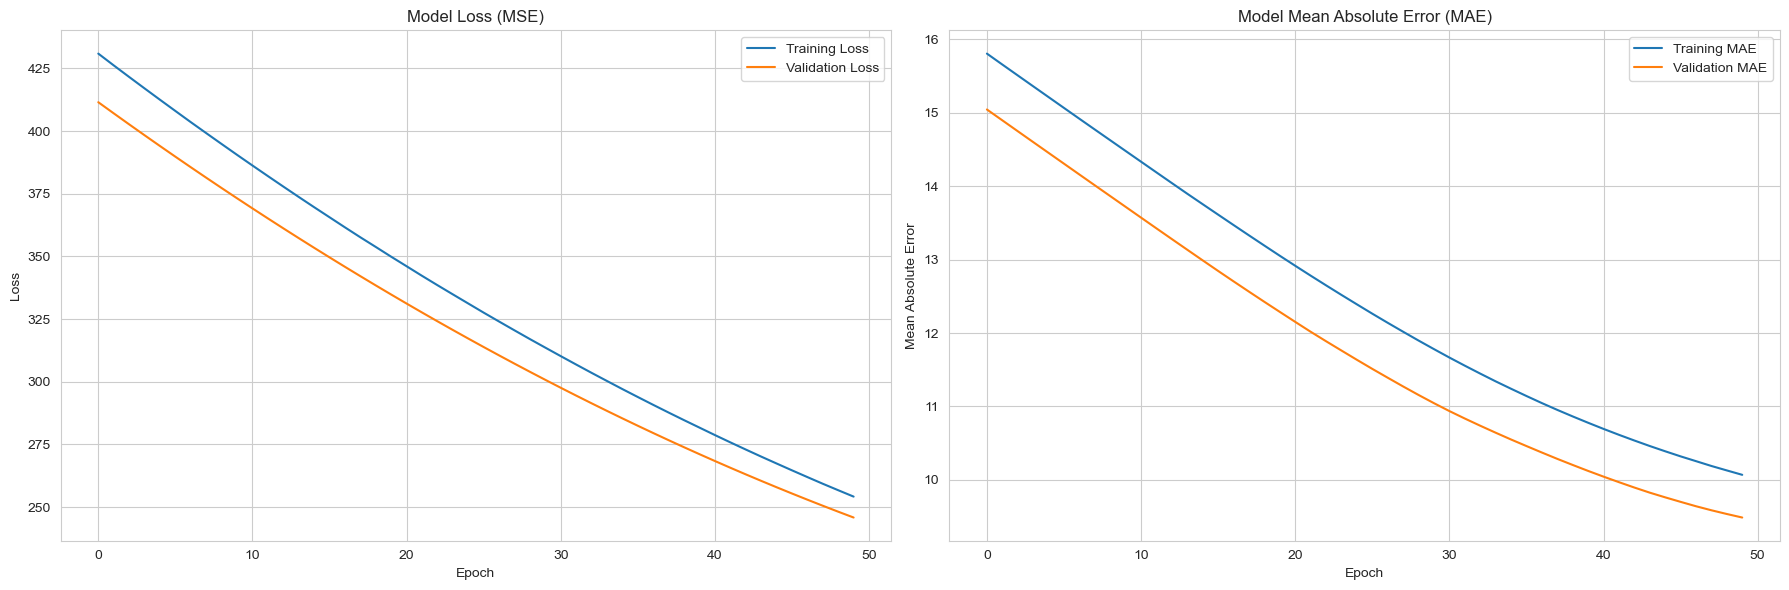

In [19]:
print("--- Plotting training and validation history ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot Loss (Mean Squared Error)
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Metric (Mean Absolute Error)
ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Model Mean Absolute Error (MAE)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.legend()

plt.tight_layout()
plt.show()

In [20]:
print("--- Final Evaluation on the Validation Set ---")
final_loss, final_mae = model.evaluate(val_dataset, verbose=0)

print(f"Final Validation Loss (MSE): {final_loss:.4f}")
print(f"Final Validation Mean Absolute Error (MAE): {final_mae:.4f}")

# Save the model weights with a descriptive name
weights_path = os.path.join(MODELS_DIR, "tcnn_model_final.weights.h5")
model.save_weights(weights_path)

print(f"\nModel weights saved to: {weights_path}")

--- Final Evaluation on the Validation Set ---
Final Validation Loss (MSE): 245.8510
Final Validation Mean Absolute Error (MAE): 9.4872

Model weights saved to: C:\Users\Enjoy\OneDrive\Desktop\STData\models\tcnn_model_final.weights.h5
